# Mechanistic Audit of Layer-wise Belief Formation in a Transformer
## Quick Colab Demo Notebook

**Objective:** I built this notebook to show how I move from **descriptive interpretability** to **causal testing** in a transformer.

### What this notebook demonstrates
1. Residual-stream evolution across **pre-attention**, **mid-layer**, and **post-MLP** states  
2. A layer-by-layer narrative for how a candidate answer becomes dominant  
3. Direct logit attribution to identify which components push the answer  
4. Attention pattern inspection to support a mechanistic story  
5. Activation patching and head ablation to move from observation to causal evidence  

### Framing
This notebook is intentionally designed to answer two questions:
- **What does the model appear to believe at each layer?**
- **Which internal components actually cause the final answer to emerge?**

### Table of contents
1. Environment setup  
2. Imports and configuration  
3. Utility functions  
4. Load model and prompts  
5. Descriptive analysis: token emergence and residual norm evolution  
6. Direct logit attribution  
7. Attention pattern inspection  
8. Activation patching  
9. Head ablation  
10. Optional MLP / neuron drill-down  
11. Executive summary for interview delivery


## 1. Environment setup

This notebook is written for **Google Colab**.

**Recommended runtime**
- GPU preferred
- Python 3.10+
- High-RAM runtime if available

**Default model choice**
- `gpt2-small`

This is deliberate. For a quick demo artifact, a small and stable model is more important than a larger model that introduces unnecessary runtime friction.


In [1]:
# Colab setup
%pip install -q transformer-lens circuitsvis einops plotly pandas matplotlib seaborn ipywidgets

In [4]:
import importlib.metadata as md
import numpy as np
import pandas as pd
import torch
import circuitsvis as cv
import transformer_lens
from transformer_lens import HookedTransformer

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("transformer_lens:", md.version("transformer-lens"))
print("CUDA available:", torch.cuda.is_available())

numpy: 1.26.4
pandas: 2.2.2
torch: 2.10.0+cu128
transformer_lens: 2.17.0
CUDA available: True


## 2. Imports and configuration

We keep a single configuration block so we can switch prompts, target tokens, and analysis settings without editing multiple cells.


In [5]:
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from IPython.display import display, HTML, Markdown

import circuitsvis as cv
from transformer_lens import HookedTransformer, patching
from transformer_lens.utils import get_act_name

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

MODEL_NAME = "gpt2-small"

PRIMARY_PROMPT = "The capital of Germany is"
SECONDARY_PROMPT = "A company with rising revenue, expanding margins, and strong free cash flow is financially"
ACTIVE_PROMPT = PRIMARY_PROMPT

CLEAN_PROMPT = "The capital of Germany is"
CORRUPTED_PROMPT = "The capital of France is"

TARGET_ANSWER = " Berlin"
RIVAL_ANSWER = " Paris"

TOP_K = 8
MAX_HEADS_TO_DISPLAY = 6


Using device: cuda


## 3. Utility functions

These helpers keep the analysis cells readable and interview-friendly.


In [6]:
def display_section(title, body=None):
    display(Markdown(f"## {title}"))
    if body:
        display(Markdown(body))

def safe_to_single_token(model, token_str):
    token_ids = model.to_tokens(token_str, prepend_bos=False).squeeze(0).tolist()
    if len(token_ids) != 1:
        raise ValueError(
            f"Expected a single token for {token_str!r}, but got {len(token_ids)} tokens: {token_ids}"
        )
    return token_ids[0]

def token_id_to_str(model, token_id):
    return model.to_string([token_id]).replace("\n", "\\n")

def final_token_logits(logits):
    if logits.ndim == 3:
        return logits[:, -1, :]
    elif logits.ndim == 2:
        return logits[-1, :].unsqueeze(0)
    raise ValueError(f"Unexpected logits shape: {tuple(logits.shape)}")

def make_metric_for_answer(model, answer_token, rival_token=None):
    def metric(logits):
        last = final_token_logits(logits)
        answer_logit = last[:, answer_token]
        if rival_token is None:
            return answer_logit.mean()
        rival_logit = last[:, rival_token]
        return (answer_logit - rival_logit).mean()
    return metric

def show_top_predictions(model, logits_1d, k=8):
    probs = F.softmax(logits_1d, dim=-1)
    vals, idx = torch.topk(probs, k=k)
    rows = []
    for rank, (p, tok_id) in enumerate(zip(vals.tolist(), idx.tolist()), start=1):
        rows.append(
            {
                "rank": rank,
                "token_id": tok_id,
                "token": token_id_to_str(model, tok_id),
                "probability": p,
            }
        )
    return pd.DataFrame(rows)

def plot_residual_norm_evolution(labels, resid_stack_last_pos):
    norms = resid_stack_last_pos.norm(dim=-1).detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(range(len(labels)), norms, marker="o")
    ax.set_title("Residual norm evolution across checkpoints")
    ax.set_xlabel("Checkpoint index")
    ax.set_ylabel("L2 norm")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    plt.tight_layout()
    plt.show()

def plot_token_emergence(df_probs, title):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_probs["checkpoint_idx"], df_probs["target_prob"], marker="o", label=df_probs["target_token"].iloc[0])
    if "rival_prob" in df_probs.columns:
        ax.plot(df_probs["checkpoint_idx"], df_probs["rival_prob"], marker="o", label=df_probs["rival_token"].iloc[0])
    ax.set_title(title)
    ax.set_xlabel("Checkpoint index")
    ax.set_ylabel("Probability at final position")
    ax.set_xticks(df_probs["checkpoint_idx"])
    ax.set_xticklabels(df_probs["checkpoint_label"], rotation=90)
    ax.legend()
    plt.tight_layout()
    plt.show()

def build_emergence_dataframe(model, checkpoint_labels, layer_logits_last_pos, target_token, rival_token=None):
    probs = F.softmax(layer_logits_last_pos, dim=-1)
    rows = []
    for i, label in enumerate(checkpoint_labels):
        row = {
            "checkpoint_idx": i,
            "checkpoint_label": label,
            "target_token": token_id_to_str(model, target_token),
            "target_prob": probs[i, target_token].item(),
        }
        if rival_token is not None:
            row["rival_token"] = token_id_to_str(model, rival_token)
            row["rival_prob"] = probs[i, rival_token].item()
            row["logit_diff_target_minus_rival"] = (
                layer_logits_last_pos[i, target_token] - layer_logits_last_pos[i, rival_token]
            ).item()
        rows.append(row)
    return pd.DataFrame(rows)

def summarize_layer_predictions(model, checkpoint_labels, layer_logits_last_pos, k=5):
    rows = []
    for i, label in enumerate(checkpoint_labels):
        vals, idx = torch.topk(F.softmax(layer_logits_last_pos[i], dim=-1), k=k)
        preds = [
            f"{token_id_to_str(model, tok_id.item())} ({prob.item():.3f})"
            for prob, tok_id in zip(vals, idx)
        ]
        rows.append({"checkpoint_label": label, "top_predictions": " | ".join(preds)})
    return pd.DataFrame(rows)

def get_answer_rank(model, logits_1d, token_id):
    probs = F.softmax(logits_1d, dim=-1)
    sorted_ids = torch.argsort(probs, descending=True)
    rank = (sorted_ids == token_id).nonzero(as_tuple=False)
    return int(rank[0].item()) + 1

def zero_head_hook(head_idx):
    def hook_fn(z, hook):
        z = z.clone()
        z[:, :, head_idx, :] = 0.0
        return z
    return hook_fn


## 4. Load model and prompts


In [7]:
display_section("Load model")

model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
model.set_use_attn_result(True)

print("Loaded model:", MODEL_NAME)
print("n_layers:", model.cfg.n_layers)
print("n_heads:", model.cfg.n_heads)
print("d_model:", model.cfg.d_model)


## Load model

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
Loaded model: gpt2-small
n_layers: 12
n_heads: 12
d_model: 768


In [8]:
display_section(
    "Prompt setup",
    "We keep both a simple factual prompt and a more business-style prompt. "
    "The factual prompt is our anchor example because it gives a cleaner mechanistic story."
)

prompt = ACTIVE_PROMPT
tokens = model.to_tokens(prompt)
str_tokens = model.to_str_tokens(prompt)
print("Prompt:", prompt)
print("String tokens:", str_tokens)

target_token_id = safe_to_single_token(model, TARGET_ANSWER)
rival_token_id = safe_to_single_token(model, RIVAL_ANSWER)

print("Target token:", TARGET_ANSWER, "->", target_token_id)
print("Rival token :", RIVAL_ANSWER, "->", rival_token_id)


## Prompt setup

We keep both a simple factual prompt and a more business-style prompt. The factual prompt is our anchor example because it gives a cleaner mechanistic story.

Prompt: The capital of Germany is
String tokens: ['<|endoftext|>', 'The', ' capital', ' of', ' Germany', ' is']
Target token:  Berlin -> 11307
Rival token :  Paris -> 6342


## 5. Descriptive analysis: token emergence and residual norm evolution

This is the core descriptive section.

We answer:
- When does the correct answer become visible?
- How does confidence change across checkpoints?
- Does a rival token dominate early?
- How does the residual stream norm evolve through the network?


In [9]:
display_section("Run model with cache")

with torch.inference_mode():
    logits, cache = model.run_with_cache(tokens, remove_batch_dim=True)

print("Logits shape:", tuple(logits.shape))


## Run model with cache

Logits shape: (1, 6, 50257)


In [10]:
display_section(
    "Checkpoint-level residual view",
    "We inspect the accumulated residual stream with `incl_mid=True` so we can compare pre-attention, "
    "mid-layer, and post-MLP states."
)

accum_resid, checkpoint_labels = cache.accumulated_resid(
    layer=-1,
    incl_mid=True,
    return_labels=True
)

print("Accumulated residual shape:", tuple(accum_resid.shape))
print("First few checkpoint labels:", checkpoint_labels[:8])


## Checkpoint-level residual view

We inspect the accumulated residual stream with `incl_mid=True` so we can compare pre-attention, mid-layer, and post-MLP states.

Accumulated residual shape: (25, 6, 768)
First few checkpoint labels: ['0_pre', '0_mid', '1_pre', '1_mid', '2_pre', '2_mid', '3_pre', '3_mid']


In [11]:
display_section(
    "Unembed every checkpoint",
    "We apply the final normalization and unembedding so each checkpoint can be interpreted as "
    "a next-token belief over the vocabulary."
)

resid_normed = model.ln_final(accum_resid)
checkpoint_logits = model.unembed(resid_normed)
checkpoint_logits_last_pos = checkpoint_logits[:, -1, :]

emergence_df = build_emergence_dataframe(
    model=model,
    checkpoint_labels=checkpoint_labels,
    layer_logits_last_pos=checkpoint_logits_last_pos,
    target_token=target_token_id,
    rival_token=rival_token_id,
)

display(emergence_df.head(12))


## Unembed every checkpoint

We apply the final normalization and unembedding so each checkpoint can be interpreted as a next-token belief over the vocabulary.

,checkpoint_idx,checkpoint_label,target_token,target_prob,rival_token,rival_prob,logit_diff_target_minus_rival
0,0,0_pre,Berlin,4.235599e-16,Paris,1.773815e-16,0.870392
1,1,0_mid,Berlin,4.152908e-08,Paris,2.571895e-08,0.479166
2,2,1_pre,Berlin,4.119961e-07,Paris,8.712077e-08,1.553719
3,3,1_mid,Berlin,3.991572e-07,Paris,5.470166e-08,1.987461
4,4,2_pre,Berlin,1.555514e-07,Paris,1.076461e-08,2.670713
5,5,2_mid,Berlin,6.470618e-07,Paris,2.222366e-08,3.371284
6,6,3_pre,Berlin,2.754031e-07,Paris,6.886807e-09,3.688629
7,7,3_mid,Berlin,6.575794e-07,Paris,6.890545e-09,4.558416
8,8,4_pre,Berlin,2.753290e-07,Paris,9.805346e-09,3.335039
9,9,4_mid,Berlin,1.320145e-06,Paris,3.877795e-08,3.527646


## Chart: token emergence by checkpoint

This chart is one of the centerpiece visuals for the interview.

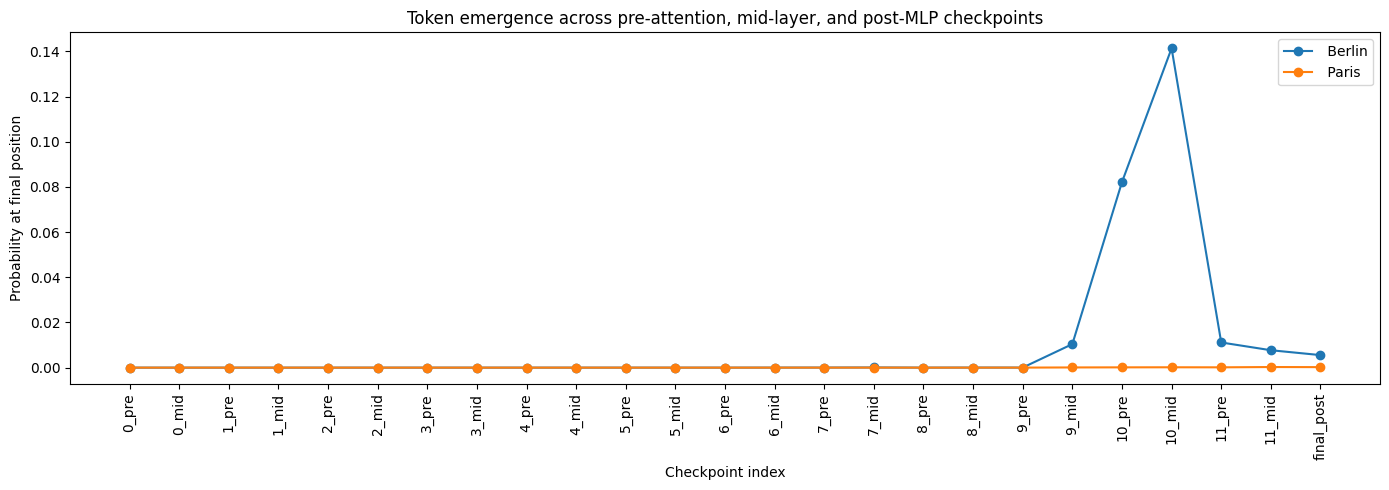

In [12]:
display_section(
    "Chart: token emergence by checkpoint",
    "This chart is one of the centerpiece visuals for this analysis."
)

plot_token_emergence(
    emergence_df,
    title="Token emergence across pre-attention, mid-layer, and post-MLP checkpoints"
)


## Chart: residual norm evolution

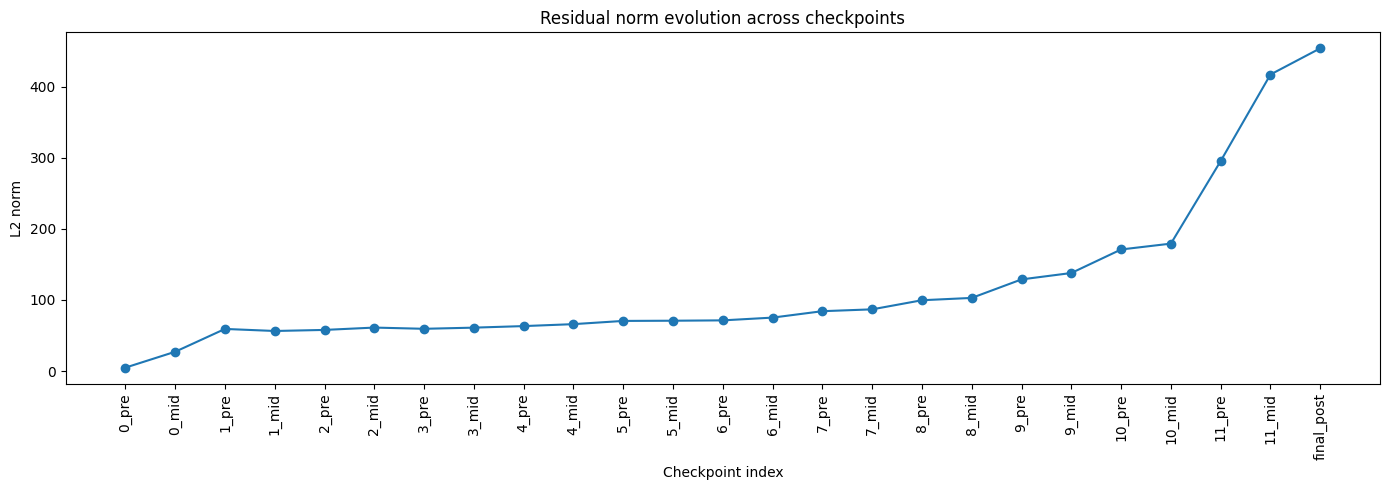

In [13]:
display_section("Chart: residual norm evolution")

resid_last_pos = accum_resid[:, -1, :]
plot_residual_norm_evolution(checkpoint_labels, resid_last_pos)


In [14]:
display_section("Top predictions at each checkpoint")

preds_df = summarize_layer_predictions(
    model=model,
    checkpoint_labels=checkpoint_labels,
    layer_logits_last_pos=checkpoint_logits_last_pos,
    k=5,
)

display(preds_df)


## Top predictions at each checkpoint

,checkpoint_label,top_predictions
0,0_pre,destro (0.772) | mathemat (0.175) | arrang ...
1,0_mid,clear (0.087) | a (0.059) | the (0.044) | ...
2,1_pre,not (0.359) | now (0.134) | still (0.088) |...
3,1_mid,not (0.289) | now (0.252) | also (0.110) | ...
4,2_pre,now (0.310) | not (0.308) | also (0.122) | ...
5,2_mid,now (0.341) | not (0.255) | also (0.111) | ...
6,3_pre,now (0.468) | not (0.165) | still (0.083) |...
7,3_mid,now (0.490) | not (0.115) | currently (0.11...
8,4_pre,now (0.605) | not (0.113) | currently (0.07...
9,4_mid,now (0.646) | not (0.101) | also (0.051) | ...


In [15]:
display_section("Final prediction at the last layer")

final_df = show_top_predictions(model, checkpoint_logits_last_pos[-1], k=TOP_K)
display(final_df)

target_rank = get_answer_rank(model, checkpoint_logits_last_pos[-1], target_token_id)
rival_rank = get_answer_rank(model, checkpoint_logits_last_pos[-1], rival_token_id)

print(f"Final rank of {TARGET_ANSWER!r}: {target_rank}")
print(f"Final rank of {RIVAL_ANSWER!r}: {rival_rank}")


## Final prediction at the last layer

,rank,token_id,token,probability
0,1,783,now,0.056738
1,2,262,the,0.044477
2,3,257,a,0.040433
3,4,1363,home,0.036467
4,5,287,in,0.028507
5,6,852,being,0.018432
6,7,739,under,0.017680
7,8,407,not,0.017465


Final rank of ' Berlin': 28
Final rank of ' Paris': 490


## 6. Direct logit attribution

Now we move from *what the model appears to believe* to *which components push the answer*.


In [16]:
display_section(
    "Direct logit attribution",
    "We decompose the residual stream into components and measure each component's contribution to the answer token."
)

resid_all, labels_all = cache.decompose_resid(layer=model.cfg.n_layers, mode="all", return_labels=True)
resid_attn, labels_attn = cache.decompose_resid(layer=model.cfg.n_layers, mode="attn", return_labels=True)
resid_mlp, labels_mlp = cache.decompose_resid(layer=model.cfg.n_layers, mode="mlp", return_labels=True)

print("All-components residual stack shape :", tuple(resid_all.shape))
print("Attention-only residual stack shape :", tuple(resid_attn.shape))
print("MLP-only residual stack shape       :", tuple(resid_mlp.shape))


## Direct logit attribution

We decompose the residual stream into components and measure each component's contribution to the answer token.

All-components residual stack shape : (26, 6, 768)
Attention-only residual stack shape : (14, 6, 768)
MLP-only residual stack shape       : (14, 6, 768)


In [17]:
display_section("Compute logit attribution scores")

logit_attrs_all = cache.logit_attrs(resid_all, TARGET_ANSWER).detach().cpu()
logit_attrs_attn = cache.logit_attrs(resid_attn, TARGET_ANSWER).detach().cpu()
logit_attrs_mlp = cache.logit_attrs(resid_mlp, TARGET_ANSWER).detach().cpu()

def attrs_to_df(labels, attrs):
    flat = attrs.squeeze()
    if flat.ndim > 1:
        flat = flat.reshape(flat.shape[0], -1).sum(dim=-1)
    return pd.DataFrame({"component": labels, "logit_attr": flat.numpy()}).sort_values("logit_attr", ascending=False)

dla_all_df = attrs_to_df(labels_all, logit_attrs_all)
dla_attn_df = attrs_to_df(labels_attn, logit_attrs_attn)
dla_mlp_df = attrs_to_df(labels_mlp, logit_attrs_mlp)

display(Markdown("### Top contributors across all components"))
display(dla_all_df.head(15))
display(Markdown("### Top attention contributors"))
display(dla_attn_df.head(15))
display(Markdown("### Top MLP contributors"))
display(dla_mlp_df.head(15))


## Compute logit attribution scores

### Top contributors across all components

,component,logit_attr
21,9_mlp_out,6.813038
23,10_mlp_out,4.805825
25,11_mlp_out,4.761717
20,9_attn_out,2.707002
17,7_mlp_out,1.924101
19,8_mlp_out,1.852587
3,0_mlp_out,1.664349
15,6_mlp_out,1.586198
7,2_mlp_out,1.442409
5,1_mlp_out,1.311817


### Top attention contributors

,component,logit_attr
11,9_attn_out,2.707002
12,10_attn_out,1.237125
13,11_attn_out,1.036061
10,8_attn_out,0.770347
8,6_attn_out,0.718260
7,5_attn_out,0.462583
5,3_attn_out,0.349343
1,pos_embed,0.293877
9,7_attn_out,0.227572
0,embed,0.221236


### Top MLP contributors

,component,logit_attr
11,9_mlp_out,6.813038
12,10_mlp_out,4.805825
13,11_mlp_out,4.761717
9,7_mlp_out,1.924101
10,8_mlp_out,1.852587
2,0_mlp_out,1.664349
8,6_mlp_out,1.586198
4,2_mlp_out,1.442409
3,1_mlp_out,1.311817
7,5_mlp_out,1.122795


## Chart: top direct logit attribution contributors

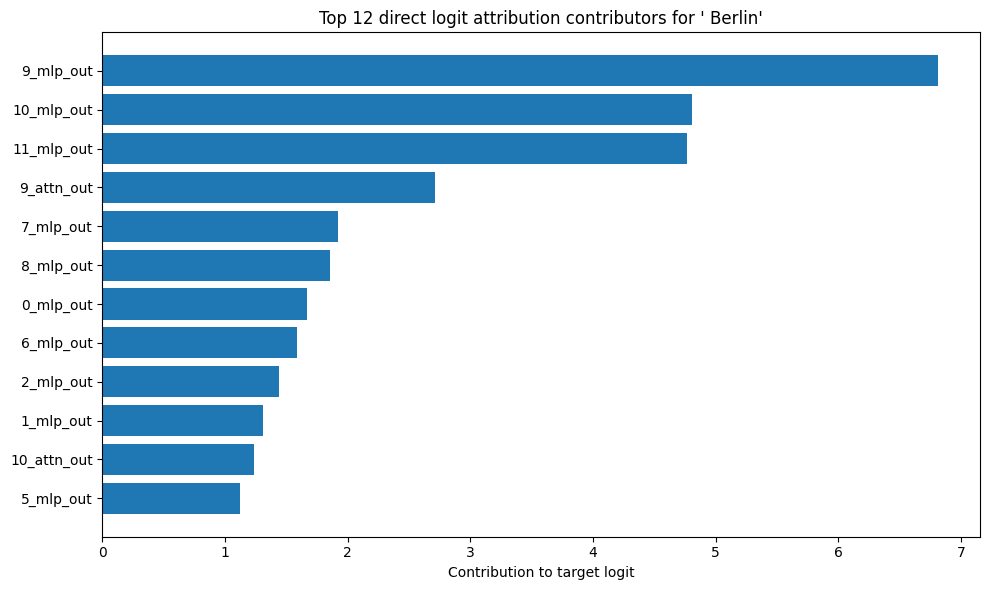

In [18]:
display_section("Chart: top direct logit attribution contributors")

top_n = 12
plot_df = dla_all_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["component"], plot_df["logit_attr"])
ax.set_title(f"Top {top_n} direct logit attribution contributors for {TARGET_ANSWER!r}")
ax.set_xlabel("Contribution to target logit")
plt.tight_layout()
plt.show()


## 7. Attention pattern inspection

Attention patterns are supporting evidence, not proof by themselves.


In [19]:
display_section("Inspect attention patterns")

candidate_attn_components = [c for c in dla_attn_df["component"].tolist() if "_attn_out" in c][:MAX_HEADS_TO_DISPLAY]
candidate_layers = sorted({int(c.split("_")[0]) for c in candidate_attn_components})

print("Candidate attention components:", candidate_attn_components)
print("Candidate layers:", candidate_layers)


## Inspect attention patterns

Candidate attention components: ['9_attn_out', '10_attn_out', '11_attn_out', '8_attn_out', '6_attn_out', '5_attn_out']
Candidate layers: [5, 6, 8, 9, 10, 11]


In [20]:
display_section("Interactive attention pattern views with CircuitsVis")

for layer in candidate_layers[:3]:
    print(f"\nLayer {layer} attention patterns")
    pattern = cache["pattern", layer]
    display(cv.attention.attention_patterns(tokens=str_tokens, attention=pattern))


## Interactive attention pattern views with CircuitsVis


Layer 5 attention patterns



Layer 6 attention patterns



Layer 8 attention patterns


## 8. Activation patching

This is the main causal section.


In [21]:
display_section("Clean vs corrupted setup")

clean_tokens = model.to_tokens(CLEAN_PROMPT)
corrupted_tokens = model.to_tokens(CORRUPTED_PROMPT)

assert clean_tokens.shape == corrupted_tokens.shape, "For a clean patching demo, prompt token lengths should match."

with torch.inference_mode():
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

metric = make_metric_for_answer(model, target_token_id, rival_token_id)

baseline_clean = metric(clean_logits).item()
baseline_corrupted = metric(corrupted_logits).item()

print("Clean metric      :", baseline_clean)
print("Corrupted metric  :", baseline_corrupted)


## Clean vs corrupted setup

Clean metric      : 3.23153018951416
Corrupted metric  : -1.8545608520507812


In [22]:
display_section("Block-level activation patching")

block_patch = patching.get_act_patch_block_every(
    model=model,
    corrupted_tokens=corrupted_tokens,
    clean_cache=clean_cache,
    metric=metric,
).detach().cpu()

patch_types = ["resid_pre", "attn_out", "mlp_out"]
print("Block patch tensor shape:", tuple(block_patch.shape))


## Block-level activation patching

  0%|          | 0/72 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]

Block patch tensor shape: (3, 12, 6)


## Chart: block-level patching heatmaps

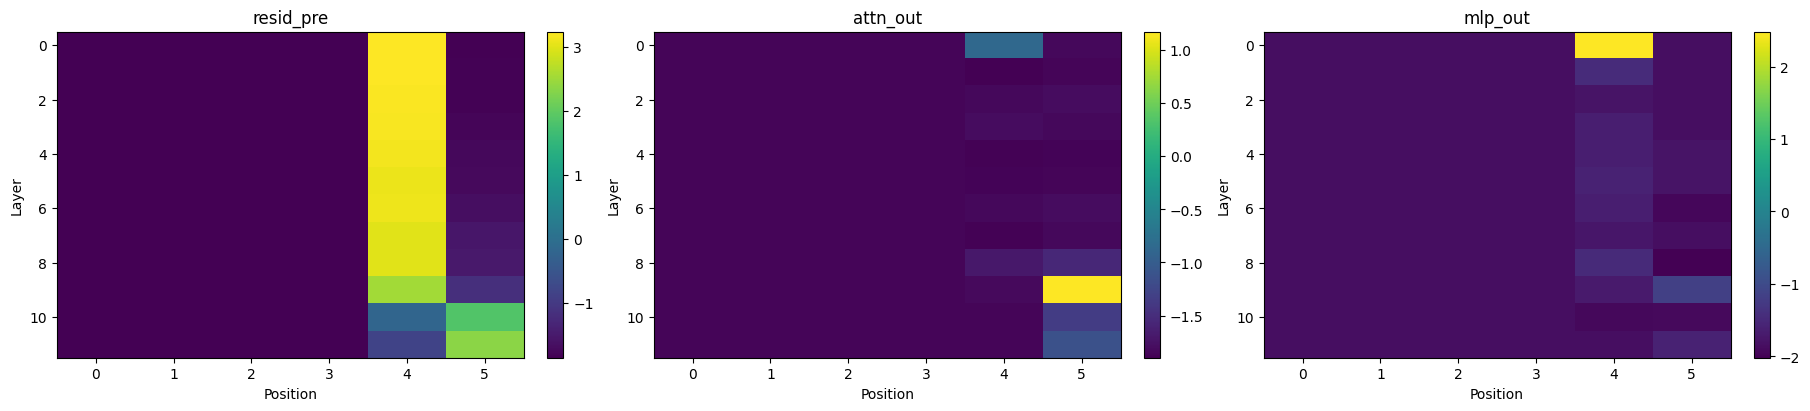

In [23]:
display_section("Chart: block-level patching heatmaps")

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
for i, name in enumerate(patch_types):
    ax = axes[i]
    im = ax.imshow(block_patch[i].numpy(), aspect="auto")
    ax.set_title(name)
    ax.set_xlabel("Position")
    ax.set_ylabel("Layer")
    fig.colorbar(im, ax=ax)
plt.show()


In [24]:
display_section("Head-level activation patching")

head_patch_all = patching.get_act_patch_attn_head_all_pos_every(
    model=model,
    corrupted_tokens=corrupted_tokens,
    clean_cache=clean_cache,
    metric=metric,
).detach().cpu()

head_patch_types = ["out", "q", "k", "v", "pattern"]
print("Head patch tensor shape:", tuple(head_patch_all.shape))


## Head-level activation patching

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

Head patch tensor shape: (5, 12, 12)


## Chart: head-level patching heatmaps

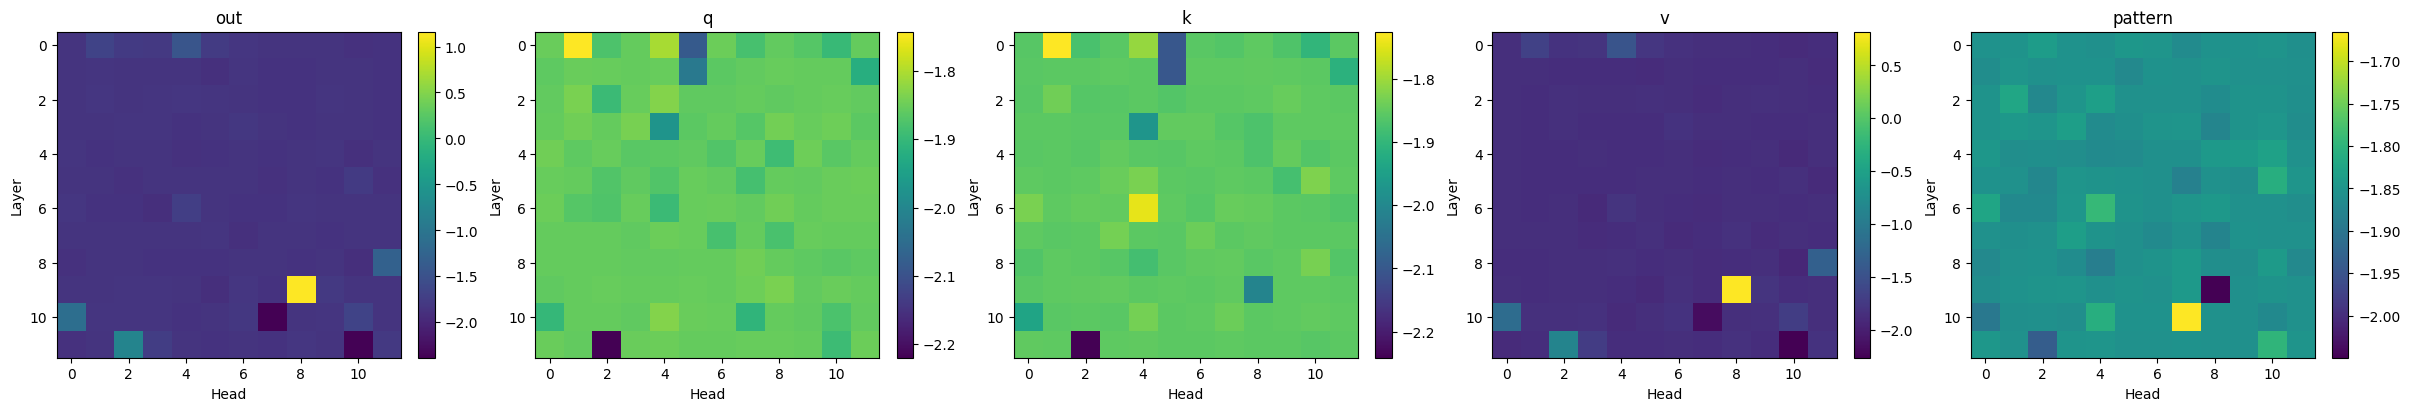

In [25]:
display_section("Chart: head-level patching heatmaps")

fig, axes = plt.subplots(1, 5, figsize=(24, 4), constrained_layout=True)
for i, name in enumerate(head_patch_types):
    ax = axes[i]
    im = ax.imshow(head_patch_all[i].numpy(), aspect="auto")
    ax.set_title(name)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    fig.colorbar(im, ax=ax)
plt.show()


In [26]:
display_section("Top candidate heads from patching")

head_out_scores = head_patch_all[0]
rows = []
for layer in range(head_out_scores.shape[0]):
    for head in range(head_out_scores.shape[1]):
        rows.append({"layer": layer, "head": head, "patch_score": head_out_scores[layer, head].item()})

top_heads_df = pd.DataFrame(rows).sort_values("patch_score", ascending=False)
display(top_heads_df.head(15))


## Top candidate heads from patching

,layer,head,patch_score
116,9,8,1.161723
134,11,2,-0.791261
120,10,0,-1.110321
107,8,11,-1.285823
4,0,4,-1.454455
1,0,1,-1.671027
130,10,10,-1.672314
76,6,4,-1.724521
135,11,3,-1.735036
5,0,5,-1.763062


## 9. Head ablation


In [27]:
display_section("Single-head ablation utility")

def ablate_single_head_and_score(model, prompt, layer, head, target_token, rival_token=None):
    tokens = model.to_tokens(prompt)
    metric_fn = make_metric_for_answer(model, target_token, rival_token)

    with torch.inference_mode():
        baseline_logits = model(tokens)
        baseline_score = metric_fn(baseline_logits).item()
        ablated_logits = model.run_with_hooks(
            tokens,
            fwd_hooks=[(get_act_name("z", layer), zero_head_hook(head))]
        )
        ablated_score = metric_fn(ablated_logits).item()

    return {
        "layer": layer,
        "head": head,
        "baseline_score": baseline_score,
        "ablated_score": ablated_score,
        "delta": ablated_score - baseline_score,
    }


## Single-head ablation utility

In [28]:
display_section("Ablate top candidate heads")

candidate_top = top_heads_df.head(8)
ablation_rows = []

for _, row in candidate_top.iterrows():
    ablation_rows.append(
        ablate_single_head_and_score(
            model=model,
            prompt=CLEAN_PROMPT,
            layer=int(row["layer"]),
            head=int(row["head"]),
            target_token=target_token_id,
            rival_token=rival_token_id,
        )
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("delta")
display(ablation_df)


## Ablate top candidate heads

,layer,head,baseline_score,ablated_score,delta
1,11,2,3.23153,2.803594,-0.427937
0,9,8,3.23153,2.843793,-0.387737
2,10,0,3.23153,2.993566,-0.237965
5,0,1,3.23153,3.152582,-0.078948
6,10,10,3.23153,3.162250,-0.069281
3,8,11,3.23153,3.172946,-0.058584
4,0,4,3.23153,3.234349,0.002819
7,6,4,3.23153,3.275034,0.043504


## Chart: head ablation deltas

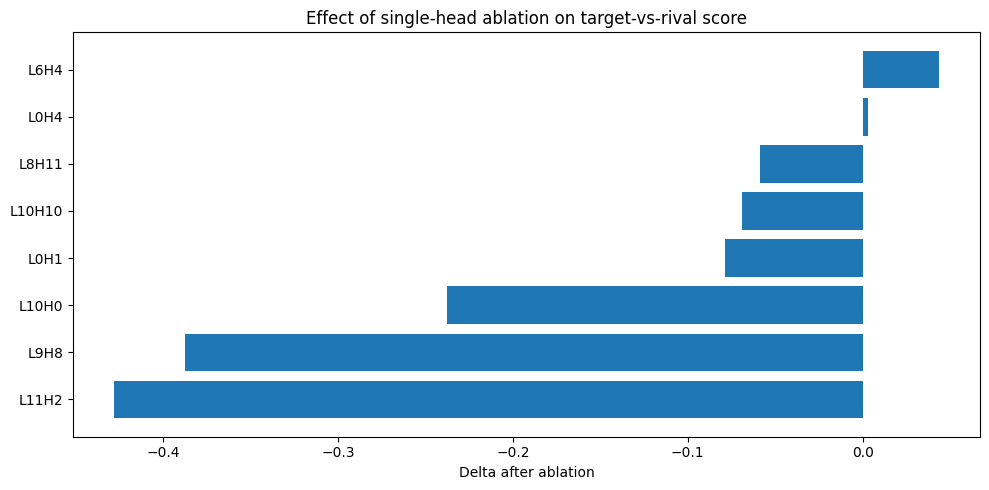

In [29]:
display_section("Chart: head ablation deltas")

plot_df = ablation_df.copy()
plot_df["label"] = plot_df.apply(lambda r: f"L{int(r['layer'])}H{int(r['head'])}", axis=1)
plot_df = plot_df.sort_values("delta")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df["label"], plot_df["delta"])
ax.set_title("Effect of single-head ablation on target-vs-rival score")
ax.set_xlabel("Delta after ablation")
plt.tight_layout()
plt.show()


## 10. Optional MLP / neuron drill-down


In [30]:
display_section("Optional MLP drill-down")

try:
    full_resid, full_labels = cache.get_full_resid_decomposition(layer=model.cfg.n_layers, return_labels=True)
    full_attrs = cache.logit_attrs(full_resid, TARGET_ANSWER).detach().cpu()
    flat = full_attrs.squeeze()
    if flat.ndim > 1:
        flat = flat.reshape(flat.shape[0], -1).sum(dim=-1)

    full_df = pd.DataFrame({"component": full_labels, "logit_attr": flat.numpy()}).sort_values("logit_attr", ascending=False)
    display(full_df.head(25))
except Exception as e:
    print("Optional neuron-level drill-down was skipped.")
    print("Reason:", repr(e))


## Optional MLP drill-down

Optional neuron-level drill-down was skipped.
Reason: RuntimeError('Inference tensors cannot be saved for backward. Please do not use Tensors created in inference mode in computation tracked by autograd. To work around this, you can make a clone to get a normal tensor and use it in autograd, or use `torch.no_grad()` instead of `torch.inference_mode()`.')


## 11. Executive summary for interview delivery

### Suggested delivery
1. **I start with a descriptive view of the residual stream**
2. **I quantify which components push the answer**
3. **I move from observation to causality**
4. **I use attention patterns as supporting evidence**

### Why this is interview-relevant
This demonstrates:
- transformer internals understanding
- model auditability
- mechanistic interpretability
- experimental discipline
- the ability to move from visual intuition to causal evidence
